<a href="https://colab.research.google.com/github/hitarthi45/Artificial-Intelligence/blob/main/Reinforcement_learning(lab_13).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

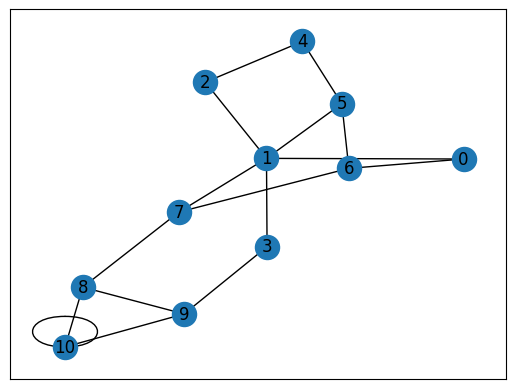

(0, 1)
(1, 5)
(5, 6)
(5, 4)
(1, 2)
(1, 3)
(9, 10)
(2, 4)
(0, 6)
(6, 7)
(8, 9)
(7, 8)
(1, 7)
(3, 9)
(10, 8)
(10, 10)
[[ -1.   0.  -1.  -1.  -1.  -1.   0.  -1.  -1.  -1.  -1.]
 [  0.  -1.   0.   0.  -1.   0.  -1.   0.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.   0.  -1.  -1.  -1.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.  -1.  -1.  -1.  -1.  -1.   0.  -1.]
 [ -1.  -1.   0.  -1.  -1.   0.  -1.  -1.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.   0.  -1.   0.  -1.  -1.  -1.  -1.]
 [  0.  -1.  -1.  -1.  -1.   0.  -1.   0.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.  -1.  -1.   0.  -1.   0.  -1.  -1.]
 [ -1.  -1.  -1.  -1.  -1.  -1.  -1.   0.  -1.   0. 100.]
 [ -1.  -1.  -1.   0.  -1.  -1.  -1.  -1.   0.  -1. 100.]
 [ -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.   0.   0. 100.]]
available actions:  [0 2 3 5 7]
next actions:  5
Before Q matrix: 
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

/tmp/ipykernel_11455/3591224371.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_action = int(np.random.choice(available_action, 1))
/tmp/ipykernel_11455/3591224371.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_index = int(np.random.choice(max_index, size = 1))   #it will give output in aarray format
/tmp/ipykernel_11455/3591224371.py:66: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_index = int(max_index)   #It will be in the array format


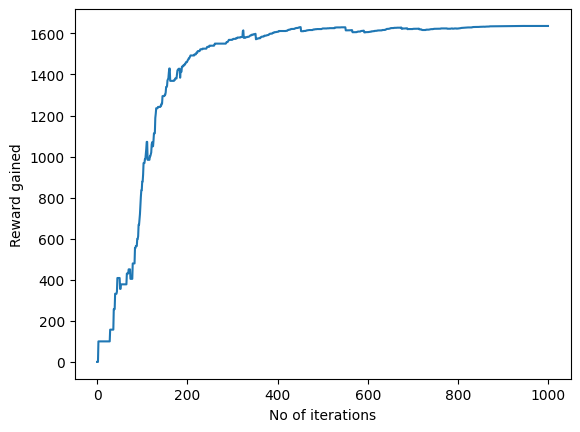

Most efficient path:
[2, 1, 7, 8, 10]


/tmp/ipykernel_11455/3591224371.py:104: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_step_index = int(next_step_index)
/tmp/ipykernel_11455/3591224371.py:102: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_step_index = int(np.random.choice(next_step_index, size = 1))


In [ ]:
import numpy as np
import pylab as pl
import networkx as nx
edges = [(0, 1), (1, 5), (5, 6), (5, 4), (1, 2),
    (1, 3), (9, 10), (2, 4), (0, 6), (6, 7),
    (8, 9), (7, 8), (1, 7), (3, 9),(10,8),(10,10)]

goal = 10
G = nx.Graph()
G.add_edges_from(edges)
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)
pl.show()
MATRIX_SIZE = 11
R = np.matrix(np.ones(shape =(MATRIX_SIZE, MATRIX_SIZE)))
R *= -1

for point in edges:
  print(point)
  if point[1] == goal:  #GOAL IS 10
    R[point] = 100
  else:
    R[point] = 0

  if point[0] == goal:
    R[point[::-1]] = 100    #SEQUENCE [START: STOP: STEP] shows the output in reverse order.  (9->10) gets reward but (10,9) doesn't
  else:
    R[point[::-1]]= 0   #REVERSE ALSO SAME POINT AS O
    # reverse of point

R[goal, goal]= 100
print(R)
# add goal point round trip
Q = np.matrix(np.zeros([MATRIX_SIZE, MATRIX_SIZE]))

gamma = 0.75
# learning parameter
initial_state = 1

# Determines the available actions for a given state
def available_actions(state):
  current_state_row = R[state, ]
  available_action = np.where(current_state_row >= 0)[1]
  return available_action

available_action = available_actions(initial_state)
print("available actions: ", available_action)
# Chooses one of the available actions at random
def sample_next_action(available_actions_range):
  next_action = int(np.random.choice(available_action, 1))
  return next_action


action = sample_next_action(available_action)
print("next actions: ", action)

def update(current_state, action, gamma):
  max_index = np.where(Q[action, ] == np.max(Q[action, ]))[1]
  if max_index.shape[0] > 1:
    print("max_index: ",max_index)
    max_index = int(np.random.choice(max_index, size = 1))   #it will give output in aarray format
  else:
    print("max_index: ",max_index)
    max_index = int(max_index)   #It will be in the array format
  max_value = Q[action, max_index]
  Q[current_state, action] = R[current_state, action] + gamma * max_value
  if (np.max(Q) > 0):
    return(np.sum(Q / np.max(Q)*100))
  else:
    return (0)
# Updates the Q-Matrix according to the path chosen
print("Before Q matrix: ")
print(Q)
update(initial_state, action, gamma)
print("After Q matrix: ")
print(Q)
scores = []
for i in range(1000):
  current_state = np.random.randint(0, int(Q.shape[0]))
  available_action = available_actions(current_state)
  action = sample_next_action(available_action)
  score = update(current_state, action, gamma)
  scores.append(score)

print("Trained Q matrix:")
print(Q / np.max(Q)*100)
# You can uncomment the above two lines to view the trained Q matrix

pl.plot(scores)
pl.xlabel('No of iterations')
pl.ylabel('Reward gained')
pl.show()
current_state = 2
steps = [current_state]

while current_state != 10:

  next_step_index = np.where(Q[current_state, ] == np.max(Q[current_state, ]))[1]
  if next_step_index.shape[0] > 1:
    next_step_index = int(np.random.choice(next_step_index, size = 1))
  else:
    next_step_index = int(next_step_index)
  steps.append(next_step_index)
  current_state = next_step_index

print("Most efficient path:")
print(steps)